In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully")

Libraries imported successfully


In [38]:
df = pd.read_csv("malicious_phish.csv")

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully
Dataset shape: (651191, 2)

Column names:
['url', 'type']

First 5 rows:


,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


New dataset shape: (641125, 2)

Value counts in 'type' column:
type
benign        428080
defacement     95308
phishing       94092
malware        23645
Name: count, dtype: int64


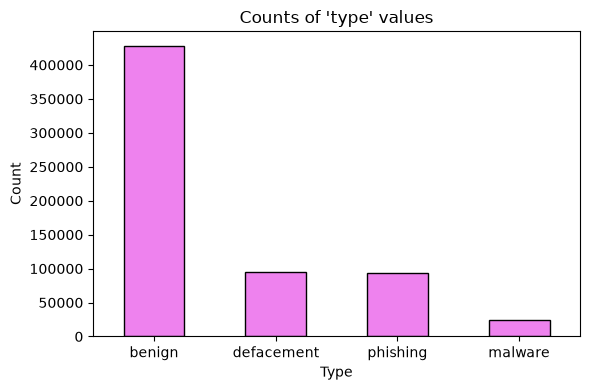

In [39]:
df_copy = df.copy()


df_copy = df_copy.drop_duplicates()


print(f"New dataset shape: {df_copy.shape}")


type_counts = df_copy['type'].value_counts()
print("\nValue counts in 'type' column:")
print(type_counts)


plt.figure(figsize=(6, 4))
type_counts.plot(kind='bar', color='violet', edgecolor='black')
plt.title("Counts of 'type' values")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
print("Dataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nURL type counts:")
print(df["type"].value_counts())

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 651191 entries, 0 to 651190
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   url     651191 non-null  str  
 1   type    651191 non-null  str  
dtypes: str(2)
memory usage: 9.9 MB
None

Missing values:
url     0
type    0
dtype: int64

Duplicate rows:
10066

URL type counts:
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64


In [41]:
df = df_copy.copy()

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (641125, 2)


In [47]:
# URL feature extraction

df["url_length"] = df["url"].str.len()
df["num_digits"] = df["url"].str.count(r"\d")
df["num_letters"] = df["url"].str.count(r"[A-Za-z]")
df["num_special_chars"] = df["url"].str.count(r"[^A-Za-z0-9]")
df["num_dots"] = df["url"].str.count(r"\.")
df["num_hyphens"] = df["url"].str.count(r"-")

# Display features side-by-side
print(df[[
    "url",
    "url_length",
    "num_digits",
    "num_letters",
    "num_special_chars",
    "num_dots",
    "num_hyphens"
]].head())

                                                 url  url_length  num_digits  \
0                                   br-icloud.com.br          16           0   
1                mp3raid.com/music/krizz_kaliko.html          35           1   
2                    bopsecrets.org/rexroth/cr/1.htm          31           1   
3  http://www.garage-pirenne.be/index.php?option=...          88           7   
4  http://adventure-nicaragua.net/index.php?optio...         235          22   

   num_letters  num_special_chars  num_dots  num_hyphens  
0           13                  3         2            1  
1           29                  5         2            0  
2           25                  5         2            0  
3           63                 18         3            1  
4          199                 14         2            1  


In [49]:
import re
from urllib.parse import urlparse

# IPv4 address pattern
ipv4_pattern = re.compile(
    r'^('
    r'(25[0-5]|2[0-4]\d|1\d\d|[1-9]?\d)\.){3}'
    r'(25[0-5]|2[0-4]\d|1\d\d|[1-9]?\d)$'
)

# Check whether the URL uses an IP address
def check_ip(url):
    try:
        hostname = urlparse(url).hostname

        if hostname and ipv4_pattern.match(hostname):
            return 1

        return 0

    except Exception:
        return 0

# Create IP address feature
df["has_ip"] = df["url"].apply(check_ip)

# Check results
print(df[["url", "has_ip"]].head())

print("\nIP address counts:")
print(df["has_ip"].value_counts())

                                                 url  has_ip
0                                   br-icloud.com.br       0
1                mp3raid.com/music/krizz_kaliko.html       0
2                    bopsecrets.org/rexroth/cr/1.htm       0
3  http://www.garage-pirenne.be/index.php?option=...       0
4  http://adventure-nicaragua.net/index.php?optio...       0

IP address counts:
has_ip
0    629037
1     12088
Name: count, dtype: int64


In [50]:
# Detect digits used inside words
digit_in_word = re.compile(r'[a-z][01]+[a-z]')

# Check for look-alike characters
def check_lookalike(url):
    try:
        if "://" not in url:
            url = "http://" + url

        hostname = urlparse(url).hostname

        if not hostname:
            return 0

        # Check for non-ASCII characters
        if not hostname.isascii():
            return 1

        # Check for punycode
        if "xn--" in hostname:
            return 1

        # Check for digits replacing letters
        if not ipv4_pattern.match(hostname):
            labels = hostname.split(".")[:-1]

            if any(digit_in_word.search(label) for label in labels):
                return 1

        return 0

    except Exception:
        return 0

# Create look-alike feature
df["has_lookalike"] = df["url"].apply(check_lookalike)

# Check results
print("\nLook-alike counts:")
print(df["has_lookalike"].value_counts())


Look-alike counts:
has_lookalike
0    636171
1      4954
Name: count, dtype: int64


In [51]:
print("\nLook-alike rate by URL type:")
print(df.groupby("type")["has_lookalike"].mean())


Look-alike rate by URL type:
type
benign        0.009202
defacement    0.001070
malware       0.004441
phishing      0.008587
Name: has_lookalike, dtype: float64


In [52]:
print("\nExample URLs detected as look-alike:")
print(
    df[df["has_lookalike"] == 1]["url"]
    .sample(20, random_state=1)
    .tolist()
)


Example URLs detected as look-alike:
['www.paypal.com.wpjsvx0ljnxvxd5pnczgk3olpztff9uzs7egwrv1gcepixsc355ujwinqirag9.adityacalibrationservice.com/', '9d345009-a-62cb3a1a-s-sites.googlegroups.com/site/stickamcomlogindo/login.html?attachauth=ANoY7cqQQfKh8Ahn4WOLWe8EiBSi9uRqBz3kiyovb5rgLLGo7yplsMpUOpQNA9OefHlSyJtzeRxwAUNsAs1pPTQx3KVjLu-GCAAnKHfa_cgxbeYPlb2SI8zFB5NmpktrV9cFIwA71QnndiLk_fxEFlgNl7DjRyX3a_EmLMKSPkKwuYO8pz5kWuvbNdFIezdXS25MQRL3qrNUzTdYswUVxqTJux3gdiEBSw==&amp;attredirects=1', "'9d345009-a-62cb3a1a-s-sites.googlegroups.com/site/stickamcomlogindo/login.html?amp\\%3Battredirects=0&amp;attachauth=ANoY7coztNuSrkhM0iPjju1trmFGeWoIOuo8oCirO5qudnz0vyuQy7GHvqVXqvgHGfqXztxBHa2w6U1HH7ijQj2y-rpX9hS_klNqIec0BQFWuojEwuOXwC6ZltvOMMaqjZ8wUgaU2g3djI0BMWUqhVknDsmgyZI0r8fezZs3Pp_m4mRfsAoEGkeOKq9UZWi4lwesuPAGa5jS3xfNqfsako3C2-Pkx6V3Rw\\%3D\\%3D&amp;attredirects=2'", 'paypal.com.webscrlcmdl.login.submit.dispatch.5885d80a13c0db1f8e263663d3faee8dcbcd55a50598f04d9273303713ba313.5885d80a2554654610545

In [53]:
from urllib.parse import urlparse

# Extract the TLD from the URL
def get_tld(url):
    try:
        # Add http if the URL does not have a protocol
        if "://" not in url:
            url = "http://" + url

        hostname = urlparse(url).hostname

        # Ignore empty hostnames and IP addresses
        if not hostname or ipv4_pattern.match(hostname):
            return ""

        parts = hostname.lower().split(".")

        if len(parts) < 2:
            return ""

        return parts[-1]

    except Exception:
        return ""

# Create TLD column
df["tld"] = df["url"].apply(get_tld)

# Define common TLDs
common_tlds = {"com", "org", "net", "edu", "gov"}

# Create TLD features
df["tld_length"] = df["tld"].str.len()
df["is_common_tld"] = df["tld"].isin(common_tlds).astype(int)

# Check results
print(df[[
    "url",
    "tld",
    "tld_length",
    "is_common_tld"
]].head())

print("\nMost common TLDs:")
print(df["tld"].value_counts().head(20))

print("\nURLs without a TLD:")
print((df["tld"] == "").sum())

print("\nNumeric TLDs:")
print(df["tld"].str.isnumeric().sum())

                                                 url  tld  tld_length  \
0                                   br-icloud.com.br   br           2   
1                mp3raid.com/music/krizz_kaliko.html  com           3   
2                    bopsecrets.org/rexroth/cr/1.htm  org           3   
3  http://www.garage-pirenne.be/index.php?option=...   be           2   
4  http://adventure-nicaragua.net/index.php?optio...  net           3   

   is_common_tld  
0              0  
1              1  
2              1  
3              0  
4              1  

Most common TLDs:
tld
com     393904
org      50768
net      28070
de       13472
         12217
uk       11946
ca       10853
edu      10077
br        8551
nl        7067
au        6395
it        5445
ru        5388
jp        4203
pl        4120
info      3384
gov       3038
fr        3021
eu        2306
vn        2187
Name: count, dtype: int64

URLs without a TLD:
12217

Numeric TLDs:
2


In [54]:
print("\nExamples of URLs without a TLD:")
print(
    df[df["tld"] == ""]["url"]
    .head(20)
    .tolist()
)


Examples of URLs without a TLD:
['77.228.191.183:7674/zeujuus/a/modules/config.bin', 'http://219.232.244.89/intl/update/error_login.htm', 'http://66.208.115.70/images/index.asp', 'http://107.21.154.157/recordings/locale/.../my.screenname.aol.com/loading.html', '216.92.161.171/vb/printthread.php?t=8432&pp=40&page=2', '77.170.120.22/ex-baba/engels/comments_on/_the_secret_swami/tigrett.htm', 'http://64.129.131.130/bin-cgi/index.html', 'http://118.69.206.95/~vihtcsn/customer/id/178976499471320573/webscr/dispatched/login.scr/info/one/', 'http://159.8.95.53/Financeiro/2Via(Boleto-Cobranca).zip', 'http://91.218.115.241/~logincom/aapf/jspaapf.IDH=sim&amp;perfil=1/', 'https://88.190.225.231:444/recordings/paypal.fr/ec/?section=signinpage&update=&cookiecheck=yes&destination=nba/signin', 'http://202.229.20.207/ppl_luni/webscr.htm', 'http://159.253.22.230/~service/cgi-bin/www.Accounts-paypal.com.php', '77.228.191.183:7890/zejius/5GPR0iy9/bot.exe', '199.115.25.156/aqueduct/Stakes/HollieHughes.shtm

In [55]:
feature_cols = [
    "url_length",
    "num_digits",
    "num_letters",
    "num_special_chars",
    "num_dots",
    "num_hyphens",
    "has_ip",
    "has_lookalike",
    "tld_length",
    "is_common_tld"
]

print("Feature columns:")
print(feature_cols)

print("\nMissing values:")
print(df[feature_cols].isnull().sum())

print("\nData types:")
print(df[feature_cols].dtypes)

print("\nFeature statistics:")
print(df[feature_cols].describe())

Feature columns:
['url_length', 'num_digits', 'num_letters', 'num_special_chars', 'num_dots', 'num_hyphens', 'has_ip', 'has_lookalike', 'tld_length', 'is_common_tld']

Missing values:
url_length           0
num_digits           0
num_letters          0
num_special_chars    0
num_dots             0
num_hyphens          0
has_ip               0
has_lookalike        0
tld_length           0
is_common_tld        0
dtype: int64

Data types:
url_length           Int64
num_digits           Int64
num_letters          Int64
num_special_chars    Int64
num_dots             Int64
num_hyphens          Int64
has_ip               int64
has_lookalike        int64
tld_length           int64
is_common_tld        int64
dtype: object

Feature statistics:
       url_length  num_digits  num_letters  num_special_chars  num_dots  \
count    641125.0    641125.0     641125.0           641125.0  641125.0   
mean    59.762232    5.371605    45.162082           9.228547   2.19395   
std     44.894451   11.630119 

In [56]:
# Select input features
X = df[feature_cols]

# Select target
y = df["type"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget classes:")
print(y.value_counts())

X shape: (641125, 10)
y shape: (641125,)

Target classes:
type
benign        428080
defacement     95308
phishing       94092
malware        23645
Name: count, dtype: int64


In [57]:
# Split into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True))

print("\nTesting class proportions:")
print(y_test.value_counts(normalize=True))

X_train shape: (512900, 10)
X_test shape: (128225, 10)
y_train shape: (512900,)
y_test shape: (128225,)

Training class proportions:
type
benign        0.667701
defacement    0.148657
phishing      0.146762
malware       0.036880
Name: proportion, dtype: float64

Testing class proportions:
type
benign        0.667701
defacement    0.148661
phishing      0.146758
malware       0.036880
Name: proportion, dtype: float64


In [58]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8815051666991617

Classification Report:
              precision    recall  f1-score   support

      benign       0.91      0.94      0.93     85616
  defacement       0.84      0.88      0.86     19062
     malware       0.94      0.85      0.89      4729
    phishing       0.76      0.61      0.68     18818

    accuracy                           0.88    128225
   macro avg       0.86      0.82      0.84    128225
weighted avg       0.88      0.88      0.88    128225


Confusion Matrix:
[[80808  1767   127  2914]
 [ 1882 16706    45   429]
 [  309   148  4017   255]
 [ 6088  1154    76 11500]]


In [59]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg.predict(X_test_scaled)

# KNN
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

# Evaluate both
for name, pred in [("Logistic Regression", y_pred_log_reg), ("KNN", y_pred_knn)]:
    print(f"{name} Evaluation:")
    print(f"Accuracy: {accuracy_score(y_test, pred):.3f}")
    print(f"Precision: {precision_score(y_test, pred, average='macro'):.3f}")
    print(f"Recall: {recall_score(y_test, pred, average='macro'):.3f}")
    print(f"F1-Score: {f1_score(y_test, pred, average='macro'):.3f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, pred))

    print("\nClassification Report:")
    print(classification_report(y_test, pred))

    print("=" * 50)

Logistic Regression Evaluation:
Accuracy: 0.731
Precision: 0.694
Recall: 0.502
F1-Score: 0.539

Confusion Matrix:
[[80656  3751    13  1196]
 [ 9089  9817     5   151]
 [ 2181   123  2355    70]
 [16640  1156    61   961]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.74      0.94      0.83     85616
  defacement       0.66      0.52      0.58     19062
     malware       0.97      0.50      0.66      4729
    phishing       0.40      0.05      0.09     18818

    accuracy                           0.73    128225
   macro avg       0.69      0.50      0.54    128225
weighted avg       0.69      0.73      0.68    128225

KNN Evaluation:
Accuracy: 0.871
Precision: 0.846
Recall: 0.808
F1-Score: 0.825

Confusion Matrix:
[[80108  1974   134  3400]
 [ 2103 16405    50   504]
 [  344   152  3999   234]
 [ 6340  1199   154 11125]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.90      0.9

In [ ]:
print("KNN accuracy:", round(accuracy_score(y_test, y_pred_knn), 3))
print(classification_report(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))